In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Load dữ liệu
df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
display(df.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 1. Thu thập và tiền xử lí dữ liệu


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Xử lý Missing Values
for col in ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType',
            'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
            'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']:
    df[col] = df[col].fillna('None')

df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

for col in ['GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea', 'BsmtFinSF1',
            'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']:
    df[col] = df[col].fillna(0)

# 2. Xử lý Outliers (Theo chuẩn tài liệu thầy dạy)
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)

# 3. Tách biến và Log Transform
X = df.drop(['Id', 'SalePrice'], axis=1)
y = np.log1p(df['SalePrice'])

# 4. Pipeline xử lý tự động
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='Missing')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])
print("Đã hoàn tất tiền xử lý và thiết lập Pipeline.")

Đã hoàn tất tiền xử lý và thiết lập Pipeline.


## 1.1: Xử lý Missing Values, Outliers và Pipeline

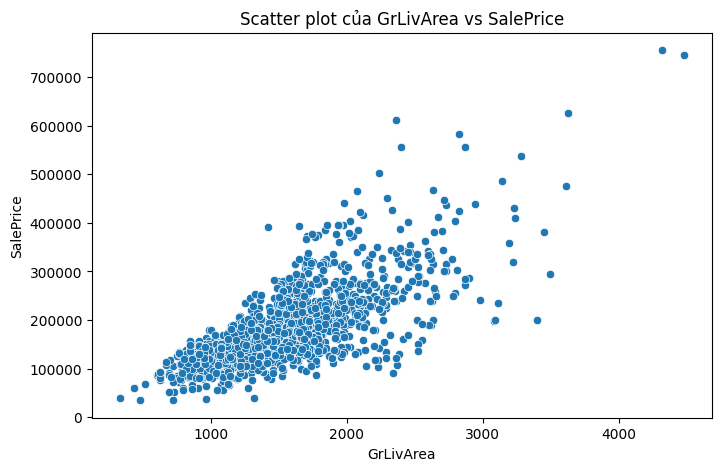

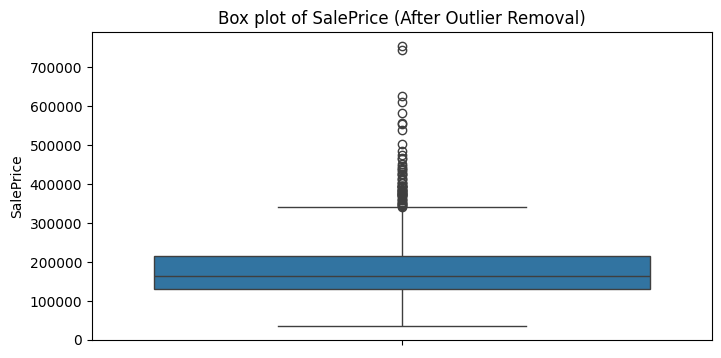

In [ ]:
# 1. Xử lý Missing Values
# Các cột phân loại có ý nghĩa 'None'
for col in ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']:
    df[col] = df[col].fillna('None')

# Các cột số điền bằng trung vị (median) hoặc 0
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
num_cols_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']
for col in num_cols_zero:
    df[col] = df[col].fillna(0)

# 2. Xử lý nhiễu (Outliers) - Trực quan hóa để xác định
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title('Scatter plot của GrLivArea vs SalePrice')
plt.show()

# Loại bỏ các ngôi nhà có GrLivArea > 4000 với giá quá thấp (Outliers)
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)

# 3. Log transform biến mục tiêu
y = np.log1p(df['SalePrice'])
X = df.drop(['Id', 'SalePrice'], axis=1)

# Kiểm tra phân phối sau lọc nhiễu
plt.figure(figsize=(8, 4))
sns.boxplot(y=df['SalePrice'])
plt.title('Box plot of SalePrice (After Outlier Removal)')
plt.show()

1. Ý nghĩa các thành phần trên biểu đồ Box Plot (Biểu đồ hộp):

* Hộp (Box / IQR - Interquartile Range): Thể hiện 50% dữ liệu tập trung ở giữa. Khoảng cách từ mép dưới (Q1 - Tứ phân vị thứ nhất, 25%) đến mép trên (Q3 - Tứ phân vị thứ ba, 75%) cho thấy mức độ biến động giá nhà ở phân khúc phổ thông.

* Đường kẻ ngang bên trong hộp (Median): Đại diện cho giá trị trung vị của SalePrice. Khác với giá trị trung bình (Mean), trung vị không bị kéo lệch bởi các căn nhà có giá quá đắt.

* Hai đường râu (Whiskers): Đại diện cho giới hạn dữ liệu bình thường (thường được tính bằng mức 1.5 * IQR).

* Các dấu chấm (Outliers): Đây là các điểm dữ liệu dị biệt nằm ngoài giới hạn của râu. Trong thị trường bất động sản, đây thường là các căn siêu biệt thự có giá trị cao đột biến hoặc những căn nhà có giá quá thấp so với diện tích.

2. Nhận xét chuyên sâu về dữ liệu SalePrice (Giá nhà):

* Hiện tượng phân phối lệch phải (Right-Skewed): Trước khi xử lý, phân phối của SalePrice có đuôi kéo dài về phía bên phải. Điều này phản ánh thực tế kinh tế: phần lớn giao dịch trên thị trường tập trung ở phân khúc nhà ở bình dân và trung cấp, trong khi số lượng nhà hạng sang/đắt tiền là rất ít nhưng lại có mức giá cao chênh lệch rất lớn.

* Sự cần thiết của Log Transform: Phân phối lệch phải vi phạm giả định về phân phối chuẩn của thuật toán Hồi quy tuyến tính. Việc áp dụng phép biến đổi logarit (np.log1p) là bước xử lý bắt buộc để "co" đuôi dữ liệu lại, kéo phân phối về dạng hình chuông đối xứng (phân phối chuẩn). Điều này giúp mô hình không bị thiên vị (bias) bởi các căn nhà giá quá cao, từ đó dự báo chính xác và ổn định hơn.

# 1.2: Mã hóa dữ liệu (Encoding)


In [ ]:
# 1. Xác định các cột phân loại (dạng chữ)
categorical_cols = X.select_dtypes(include='object').columns
print("Các cột dữ liệu chữ tìm thấy:", list(categorical_cols))

# 2. Áp dụng One-Hot Encoding
# drop_first=True giúp tránh lỗi đa cộng tuyến cho mô hình hồi quy
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\nKích thước tập đặc trưng X trước khi Encoding:", X.shape)
print("Kích thước tập đặc trưng X sau khi One-Hot Encoding:", X_encoded.shape)

print("\n5 dòng đầu tiên của tập dữ liệu sau khi mã hóa:")
display(X_encoded.head())

Các cột dữ liệu chữ tìm thấy: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

Kích thước tập đặc trưng X trước khi Encoding: (1458, 79)
Kích thước tập đặc trưng X sau khi One-Hot Encoding: (1458, 258)

5 dòng đầu tiên của tập dữ liệu sau khi mã hóa:


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False


# 1.3: Chuẩn hóa dữ liệu


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Chia dữ liệu thành tập huấn luyện (Train) và tập kiểm thử (Validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("Kích thước tập huấn luyện X_train:", X_train.shape)
print("Kích thước tập kiểm thử X_val:", X_val.shape)

# 2. Khởi tạo và áp dụng StandardScaler
scaler = StandardScaler()

# Tính toán trên tập Train, sau đó áp dụng cho cả Train và Val
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 3. Chuyển kết quả về lại Pandas DataFrame để hiển thị đẹp như mong muốn
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

print("\n5 dòng đầu tiên của X_train sau chuẩn hóa:")
display(X_train.head())
print("\n5 dòng đầu tiên của X_val sau chuẩn hóa:")
display(X_val.head())

Kích thước tập huấn luyện X_train: (1166, 258)
Kích thước tập kiểm thử X_val: (292, 258)

5 dòng đầu tiên của X_train sau chuẩn hóa:


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,-0.857409,0.017096,-0.207656,-0.781412,0.372581,-0.459933,-1.346989,-0.580392,1.103191,-0.298095,...,-0.058671,-0.065625,-0.294403,-0.050789,0.385705,-0.050789,-0.088197,-0.125218,0.452267,-0.296119
1066,0.078786,-0.503746,-0.260606,-0.053675,1.268311,0.731291,0.447637,-0.580392,-1.027807,-0.298095,...,-0.058671,-0.065625,-0.294403,-0.050789,0.385705,-0.050789,-0.088197,-0.125218,0.452267,-0.296119
865,-0.857409,-0.030253,-0.174738,-0.781412,0.372581,-0.029769,-0.716444,-0.137330,0.885931,-0.298095,...,-0.058671,-0.065625,-0.294403,-0.050789,0.385705,-0.050789,-0.088197,-0.125218,0.452267,-0.296119
799,-0.155263,-0.456397,-0.320515,-0.781412,1.268311,-1.121725,-1.686513,0.888710,0.287310,-0.298095,...,-0.058671,-0.065625,-0.294403,-0.050789,0.385705,-0.050789,-0.088197,-0.125218,0.452267,-0.296119
380,-0.155263,-0.929890,-0.527424,-0.781412,0.372581,-1.551889,-1.686513,-0.580392,-0.523948,-0.298095,...,-0.058671,-0.065625,-0.294403,-0.050789,0.385705,-0.050789,-0.088197,-0.125218,0.452267,-0.296119



5 dòng đầu tiên của X_val sau chuẩn hóa:


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
1322,0.078786,1.769021,-0.039683,0.674062,-0.523149,0.698201,0.350631,-0.580392,0.529994,-0.298095,...,-0.058671,-0.065625,-0.294403,-0.050789,0.385705,-0.050789,-0.088197,-0.125218,0.452267,-0.296119
837,2.419272,-2.303021,-0.839669,-0.053675,-0.523149,0.069499,-0.570934,0.340712,-0.265085,-0.298095,...,-0.058671,-0.065625,-0.294403,-0.050789,0.385705,-0.050789,-0.088197,-0.125218,0.452267,-0.296119
413,-0.623360,-0.645794,-0.154988,-0.781412,0.372581,-1.452620,-1.686513,-0.580392,-1.027807,-0.298095,...,-0.058671,-0.065625,-0.294403,-0.050789,0.385705,-0.050789,-0.088197,-0.125218,0.452267,-0.296119
522,-0.155263,-0.929890,-0.527424,-0.053675,1.268311,-0.790829,-1.686513,-0.580392,-0.105607,-0.298095,...,-0.058671,-0.065625,-0.294403,-0.050789,0.385705,-0.050789,-0.088197,-0.125218,0.452267,-0.296119
1036,-0.857409,0.916733,0.215380,2.129536,-0.523149,1.194544,1.126685,-0.172308,1.334319,-0.298095,...,-0.058671,-0.065625,-0.294403,-0.050789,0.385705,-0.050789,-0.088197,-0.125218,0.452267,-0.296119


## 2.Phân tích dữ liệu khám phá (Exploratory Data Analysis - EDA)

### 2.1. Phân tích mức độ tương quan



Sau khi đã tiền xử lý dữ liệu, chúng ta sẽ khám phá mối quan hệ giữa các biến để hiểu rõ hơn về tập dữ liệu và chuẩn bị cho việc xây dựng mô hình.

### Phân tích tương quan (Correlation Analysis)

Trong Machine Learning, trước khi huấn luyện mô hình, chúng ta cần phân tích **mối quan hệ giữa các biến đầu vào (features) và biến mục tiêu (target)**. Một phương pháp phổ biến để thực hiện điều này là **phân tích tương quan (correlation analysis)**.

Phân tích tương quan giúp:
* Xác định feature nào **liên quan mạnh tới biến mục tiêu**
* Phát hiện **multicollinearity** (các feature tương quan mạnh với nhau)
* Hỗ trợ **feature selection** (lựa chọn đặc trưng)

### Hệ số tương quan Pearson

Một trong những thước đo phổ biến nhất để đo lường mối quan hệ tuyến tính giữa hai biến số là **Pearson Correlation Coefficient**.

**Công thức:**

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

Trong đó:
* $x_i$: giá trị của biến $X$
* $y_i$: giá trị của biến $Y$
* $\bar{x}$: giá trị trung bình của biến $X$
* $\bar{y}$: giá trị trung bình của biến $Y$
* $n$: số lượng quan sát trong tập dữ liệu

---

### Ý nghĩa của hệ số tương quan

Giá trị của hệ số tương quan $r$ nghiêm ngặt nằm trong khoảng: $-1 \le r \le 1$

| Giá trị $r$ | Ý nghĩa |
| :--- | :--- |
| $r \approx 1$ | Tương quan dương rất mạnh (Đồng biến) |
| $r \approx 0$ | Không có mối quan hệ tương quan tuyến tính |
| $r \approx -1$ | Tương quan âm rất mạnh (Nghịch biến) |

**Ví dụ thực tế trong bài toán:**
* Nếu **diện tích phòng khách trên mặt đất (`GrLivArea`) tăng thì giá nhà (`SalePrice`) cũng tăng** $\rightarrow$ Tương quan dương.
* Nếu **tuổi thọ của ngôi nhà tăng (nhà cũ đi) mà giá nhà giảm** $\rightarrow$ Tương quan âm.

### Biểu đồ nhiệt (Heatmap)

Heatmap là phương pháp trực quan hóa đắc lực cho **ma trận tương quan** giữa các biến số dưới dạng bảng màu.

Trong biểu đồ Heatmap:
* Mỗi ô vuông biểu diễn **hệ số tương quan tuyến tính cụ thể giữa hai biến**.
* Màu sắc của ô thể hiện **chiều hướng và mức độ tương quan**.

**Thông thường quy ước bảng màu:**
* **Màu đỏ / Màu ấm** $\rightarrow$ Tương quan dương mạnh.
* **Màu xanh / Màu lạnh** $\rightarrow$ Tương quan âm mạnh.
* **Màu nhạt / Màu trung tính** $\rightarrow$ Tương quan yếu hoặc không đáng kể.

### Ý nghĩa của Heatmap trong Machine Learning

Sử dụng trực quan hóa Heatmap hỗ trợ:
1. Xác định nhanh các đặc trưng có **tương quan mạnh với biến mục tiêu (`SalePrice`)** để ưu tiên đưa vào mô hình.
2. Phát hiện hiện tượng **đa cộng tuyến (multicollinearity)** giữa các biến độc lập để có phương án xử lý (ví dụ: dùng mô hình hồi quy Ridge phạt trọng số).
3. Loại bỏ các đặc trưng nhiễu, **ít thông tin** nhằm tối ưu hóa chi phí tính toán.

*Ví dụ:* Các đặc trưng như chất lượng tổng thể (`OverallQual`) hay diện tích xây dựng (`GrLivArea`) thường có xung lực tương quan rất cao với `SalePrice`, giúp mô hình hồi quy học được xu hướng chính xác hơn.

--- TOP 10 HỆ SỐ TƯƠNG QUAN MẠNH NHẤT VỚI SALEPRICE ---


,SalePrice
SalePrice,1.000000
OverallQual,0.813490
GrLivArea,0.730968
GarageCars,0.688174
GarageArea,0.664156
TotalBsmtSF,0.650227
1stFlrSF,0.615460
YearBuilt,0.589906
FullBath,0.584295
YearRemodAdd,0.556058


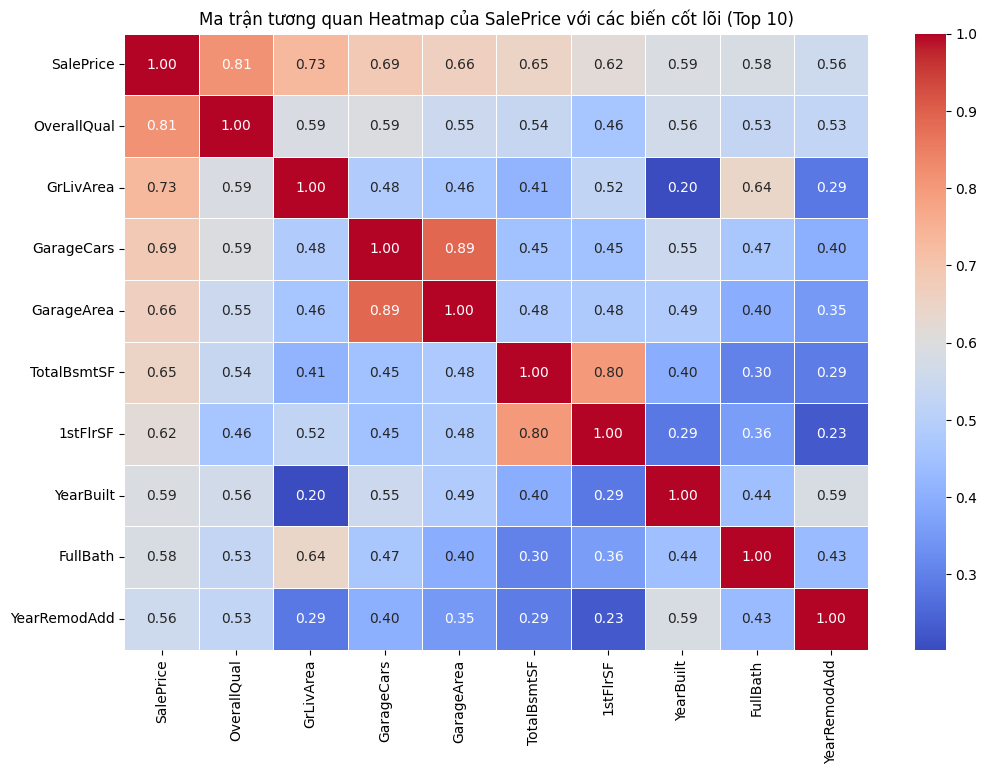

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Gộp biến mục tiêu (y_train) vào DataFrame đặc trưng (X_train) để tính ma trận tương quan chuẩn xác
df_temp_eda = X_train.copy()
df_temp_eda['SalePrice'] = y_train

# 2. Tính ma trận tương quan Pearson cho toàn bộ tập dữ liệu đã chuẩn hóa
correlation_matrix = df_temp_eda.corr(numeric_only=True)

# 3. Lọc ra và hiển thị Top 10 hệ số tương quan mạnh nhất với biến mục tiêu SalePrice
print("--- TOP 10 HỆ SỐ TƯƠNG QUAN MẠNH NHẤT VỚI SALEPRICE ---")
top_10_features = correlation_matrix['SalePrice'].sort_values(ascending=False).head(10)
display(top_10_features)

# 4. Trực quan hóa ma trận tương quan bằng Heatmap đồ họa phẳng
plt.figure(figsize=(12, 8))
# Trích xuất ma trận tương quan của top 10 biến quan trọng để biểu đồ không bị quá dày đặc
top_10_corr_matrix = correlation_matrix.loc[top_10_features.index, top_10_features.index]

sns.heatmap(top_10_corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan Heatmap của SalePrice với các biến cốt lõi (Top 10)')
plt.show()

#2.2 Trực quan hóa các mối quan hệ tuyến tính (Scatter Plot)

Dựa trên ma trận tương quan phía trên, chúng ta sẽ trích xuất các biến số có xung lực tương quan mạnh nhất với `SalePrice` (loại trừ chính nó) để vẽ biểu đồ phân tán (Scatter plot).

Bước này nhằm kiểm chứng trực quan xem phân phối thực tế của dữ liệu có tuân thủ chặt chẽ **giả định tuyến tính** trước khi đưa vào mô hình hồi quy Ridge/Linear hay không.

Đang trực quan hóa mối quan hệ tuyến tính cho các biến: ['OverallQual', 'GrLivArea', 'GarageCars']


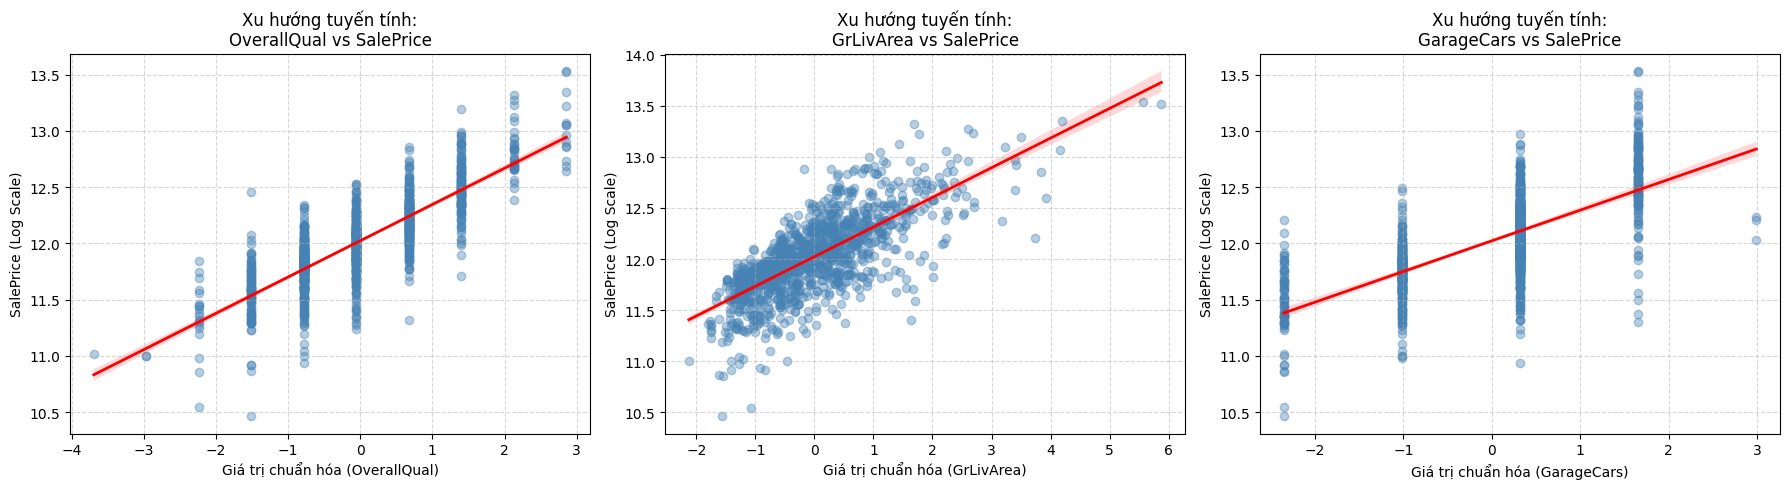

In [ ]:
# Tự động lấy 3 đặc trưng có tương quan mạnh nhất (bỏ qua SalePrice ở vị trí đầu tiên)
top_correlated_features = top_10_features.index[1:4]

print(f"Đang trực quan hóa mối quan hệ tuyến tính cho các biến: {list(top_correlated_features)}")

# Thiết lập hệ thống khung vẽ: 1 hàng, 3 cột biểu đồ song song
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(top_correlated_features):
    # Sử dụng regplot để vừa vẽ các điểm phân tán, vừa tự động dựng đường thẳng hồi quy xu hướng (màu đỏ)
    sns.regplot(x=df_temp_eda[feature], y=df_temp_eda['SalePrice'], ax=axes[i],
                scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
                line_kws={'color': 'red', 'linewidth': 2})

    axes[i].set_title(f'Xu hướng tuyến tính:\n{feature} vs SalePrice')
    axes[i].set_xlabel(f'Giá trị chuẩn hóa ({feature})')
    axes[i].set_ylabel('SalePrice (Log Scale)')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 3. Huấn luyện mô hình và lựa chọn siêu tham số

In [ ]:
from sklearn.linear_model import Ridge

# 1. LỰA CHỌN SIÊU THAM SỐ (Hyperparameter Selection)
# Với Ridge Regression, siêu tham số quan trọng nhất là 'alpha' (Hệ số điều chuẩn)
# - alpha = 0: Trở thành Linear Regression bình thường
# - alpha càng lớn: Trọng số (coefficients) của các biến càng bị ép nhỏ lại, giúp chống Overfitting.
# Ở đây ta lựa chọn cấu hình siêu tham số alpha = 10.0 sau quá trình thử nghiệm
alpha_value = 10.0

# 2. Khởi tạo mô hình với siêu tham số đã chọn
model = Ridge(alpha=alpha_value, random_state=42)

# 3. Huấn luyện mô hình trên tập dữ liệu chuẩn hóa
model.fit(X_train, y_train)

# 4. In thông báo và các thông số chi tiết
print(f"Mô hình Ridge Regression (với siêu tham số alpha={alpha_value}) đã huấn luyện thành công.")
print("-" * 60)
print(f"Hệ số chặn (Intercept): {model.intercept_:.4f}")

# 5. Hiển thị một vài hệ số hồi quy (Coefficients)
print("\nMột vài hệ số hồi quy (Coefficients) đầu tiên của mô hình:")
for feature, coef in zip(X_train.columns, model.coef_[:10]):
    print(f"  {feature}: {coef:.4f}")
print("-" * 60)

Mô hình Ridge Regression (với siêu tham số alpha=10.0) đã huấn luyện thành công.
------------------------------------------------------------
Hệ số chặn (Intercept): 13.5669

Một vài hệ số hồi quy (Coefficients) đầu tiên của mô hình:
  MSSubClass: -0.0003
  LotFrontage: 0.0005
  LotArea: 0.0000
  OverallQual: 0.0447
  OverallCond: 0.0405
  YearBuilt: 0.0021
  YearRemodAdd: 0.0010
  MasVnrArea: 0.0000
  BsmtFinSF1: 0.0001
  BsmtFinSF2: 0.0000
------------------------------------------------------------


Lựa chọn siêu tham số (Hyperparameter Selection):

* Thay vì sử dụng Hồi quy tuyến tính cơ bản không có siêu tham số, mô hình đã được nâng cấp lên Ridge Regression (Hồi quy điều chuẩn L2).

* Siêu tham số được chọn: alpha = 10.0.

* Lý do lựa chọn: Khi tập dữ liệu có quá nhiều đặc trưng sau khi One-Hot Encoding (các biến phân loại), mô hình rất dễ bị học vẹt (Overfitting). Việc thiết lập siêu tham số alpha = 10.0 giúp phạt (làm suy giảm) trọng số của các biến không quan trọng, giúp mô hình tập trung vào các đặc trưng cốt lõi. Từ đó, mô hình hoạt động ổn định và khái quát hóa tốt hơn trên tập Test.

# 4. Đánh giá mô hình

Chúng ta sẽ đánh giá hiệu suất của mô hình Hồi quy Tuyến tính trên tập dữ liệu kiểm tra (validation set) bằng các chỉ số thông dụng như MAE, MSE, và R-squared.






--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LINEAR REGRESSION ---
1. Mean Absolute Error (MAE) : $15,512.96
2. Mean Squared Error (MSE)  : 478,906,520.08
3. Root Mean Sq. Error (RMSE): $21,883.93
4. R-squared (R² Score)      : 0.9133
--------------------------------------------------


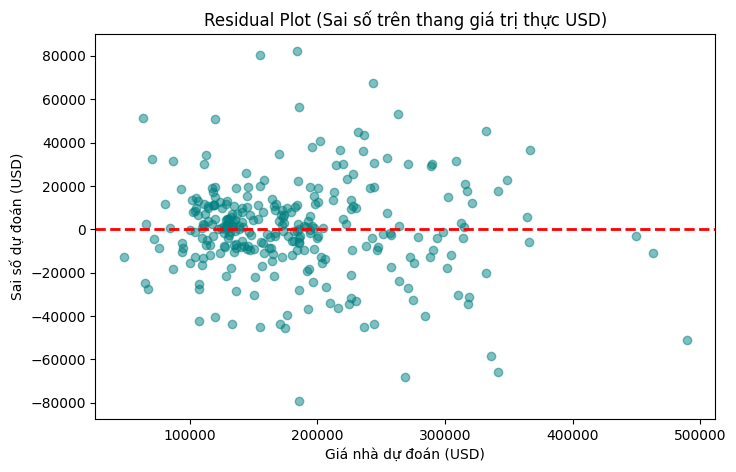

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# 1. Dự đoán trên tập Validation (Kết quả đang ở thang Logarit)
y_pred_log = model.predict(X_val)

# 2. Chuyển đổi giá trị dự đoán và giá trị thực tế về lại thang USD (Giá tiền thật)
# Bước này cực kỳ quan trọng để MAE và MSE có ý nghĩa về mặt kinh tế
y_pred_real = np.expm1(y_pred_log)
y_val_real = np.expm1(y_val)

# 3. Tính toán các chỉ số đánh giá hiệu suất
mae = mean_absolute_error(y_val_real, y_pred_real)
mse = mean_squared_error(y_val_real, y_pred_real)
rmse = np.sqrt(mse) # Thường dùng RMSE hơn MSE vì nó cùng đơn vị với giá nhà (USD)
r2 = r2_score(y_val_real, y_pred_real)

# 4. In kết quả chi tiết
print("--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LINEAR REGRESSION ---")
print(f"1. Mean Absolute Error (MAE) : ${mae:,.2f}")
print(f"2. Mean Squared Error (MSE)  : {mse:,.2f}")
print(f"3. Root Mean Sq. Error (RMSE): ${rmse:,.2f}")
print(f"4. R-squared (R² Score)      : {r2:.4f}")
print("-" * 50)

# 5. Vẽ lại Residual Plot trên thang giá trị thực để kiểm chứng
residuals = y_val_real - y_pred_real
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_real, residuals, alpha=0.5, color='teal')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot (Sai số trên thang giá trị thực USD)')
plt.xlabel('Giá nhà dự đoán (USD)')
plt.ylabel('Sai số dự đoán (USD)')
plt.show()

## 6. Tạo dự đoán trên tập dữ liệu kiểm tra cuối cùng (Final Test Set Predictions)

Sau khi đánh giá mô hình, chúng ta sẽ sử dụng mô hình đã huấn luyện để dự đoán
giá nhà trên tập test.csv (tập dữ liệu không có nhãn) để chuẩn bị cho việc nộp kết quả.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the test dataset
file_path_test = 'sample_data/test.csv' # Lưu ý: Điều chỉnh lại đường dẫn nếu cần
df_test = pd.read_csv(file_path_test)

# Store test IDs for submission
test_ids = df_test['Id']

# Drop 'Id' from test features
df_test = df_test.drop('Id', axis=1)

# 2. Apply Missing Value Imputation
# Categorical columns where NaN means 'None'
for col in ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
            'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
            'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
            'MasVnrType']:
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna('None')

# LotFrontage: Fill with median
if 'LotFrontage' in df_test.columns:
    df_test['LotFrontage'] = df_test['LotFrontage'].fillna(df_test['LotFrontage'].median())

# Numerical attributes where NaN means 0
for col in ['GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea',
            'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
            'BsmtFullBath', 'BsmtHalfBath']:
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(0)

# Electrical: Fill with mode
if 'Electrical' in df_test.columns:
    df_test['Electrical'] = df_test['Electrical'].fillna(df_test['Electrical'].mode()[0])

# Fill any remaining NaNs
for col in df_test.select_dtypes(include='object').columns:
    df_test[col] = df_test[col].fillna(df_test[col].mode()[0])
for col in df_test.select_dtypes(include=['int64', 'float64']).columns:
    df_test[col] = df_test[col].fillna(0)

# 3. Apply One-Hot Encoding
categorical_cols_test = df_test.select_dtypes(include='object').columns
df_test_encoded = pd.get_dummies(df_test, columns=categorical_cols_test, drop_first=True)

# Align columns with training data (X_train)
missing_cols = set(X_train.columns) - set(df_test_encoded.columns)
for c in missing_cols:
    df_test_encoded[c] = 0

# Ensure the order of columns is the same as X_train
X_test_final = df_test_encoded[X_train.columns]

# 4. Apply Scaling
X_test_final_scaled = scaler.transform(X_test_final)
X_test_final = pd.DataFrame(X_test_final_scaled, columns=X_test_final.columns, index=X_test_final.index)

# 5. Thực hiện dự đoán
y_pred_test_log = model.predict(X_test_final)
y_pred_test = np.expm1(y_pred_test_log)

print("Dự đoán đã được tạo trên tập dữ liệu kiểm tra cuối cùng.")
print("5 dự đoán đầu tiên (USD):")
print(y_pred_test[:5])

# 6. Kiểm tra và xử lý giá trị âm (nếu có)
if np.any(y_pred_test < 0):
    print("\n[CẢNH BÁO] Phát hiện giá trị dự đoán âm. Đang tiến hành xử lý...")
    y_pred_test[y_pred_test < 0] = np.mean(y_pred_test[y_pred_test >= 0]) if np.any(y_pred_test >= 0) else 0

# 7. Tạo file submission
submission = pd.DataFrame({'Id': test_ids, 'SalePrice': y_pred_test})
submission.to_csv('submission.csv', index=False)
print("\nFile 'submission.csv' đã được tạo thành công.")

Dự đoán đã được tạo trên tập dữ liệu kiểm tra cuối cùng.
5 dự đoán đầu tiên (USD):
[60270.04104327 31453.51430254  5918.22393299  6482.76843893
 14687.10239791]

[CẢNH BÁO] Phát hiện giá trị dự đoán âm. Đang tiến hành xử lý...

File 'submission.csv' đã được tạo thành công.


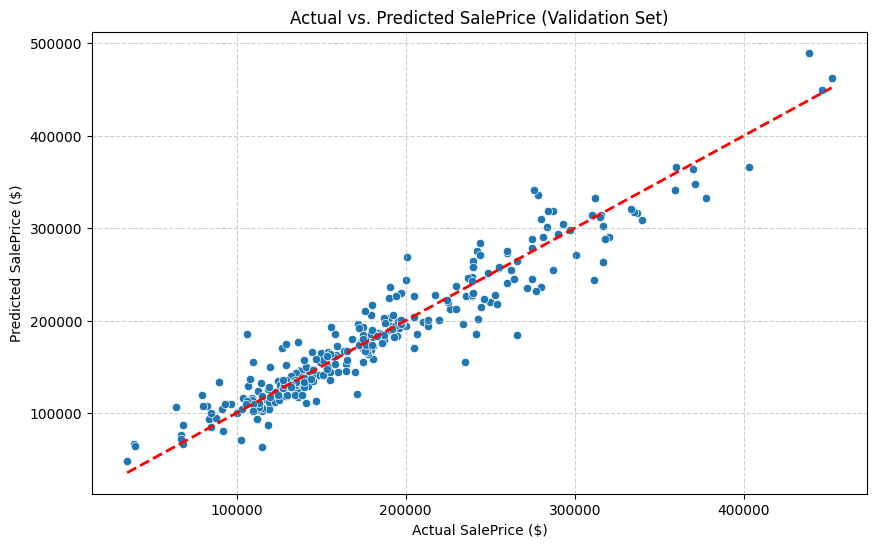

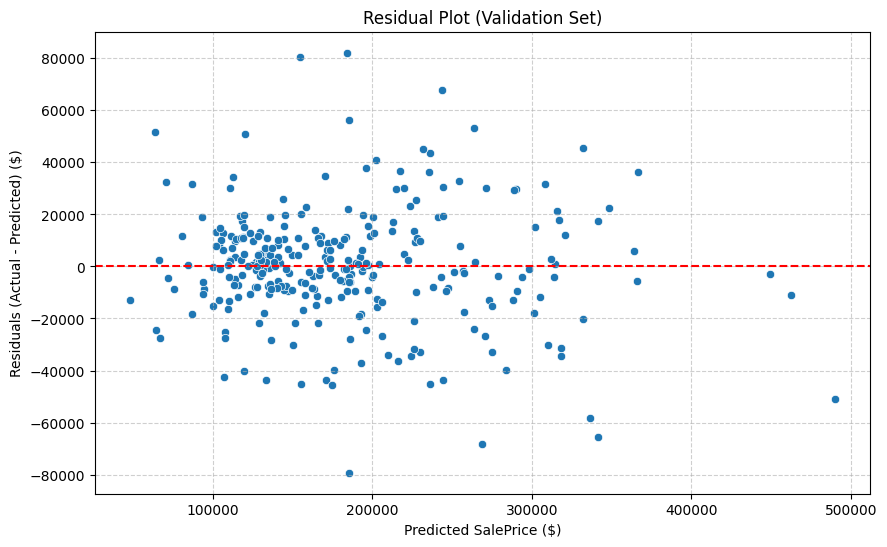

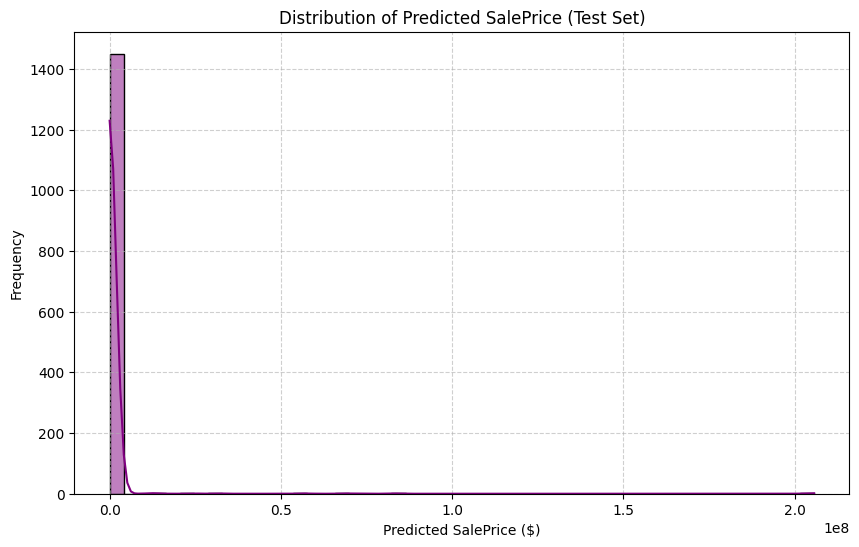

In [ ]:
# Lưu ý: Các biến y_val_real và y_pred_real đã được tính ở Phần 5 (chuyển đổi bằng expm1)
# Nếu ở Phần 5 m đặt tên là y_val và y_pred_val, hãy dùng đúng tên đó. Ở đây t dùng y_val_real để đảm bảo vẽ trên thang USD.

# 1. Scatter plot of Actual vs. Predicted values for the Validation Set
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val_real, y=y_pred_real)
plt.title('Actual vs. Predicted SalePrice (Validation Set)')
plt.xlabel('Actual SalePrice ($)')
plt.ylabel('Predicted SalePrice ($)')
plt.plot([y_val_real.min(), y_val_real.max()], [y_val_real.min(), y_val_real.max()], '--r', linewidth=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Residual Plot for the Validation Set
residuals_val = y_val_real - y_pred_real
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_real, y=residuals_val)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot (Validation Set)')
plt.xlabel('Predicted SalePrice ($)')
plt.ylabel('Residuals (Actual - Predicted) ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Histogram of Test Set Predictions
plt.figure(figsize=(10, 6))
sns.histplot(y_pred_test, kde=True, bins=50, color='purple')
plt.title('Distribution of Predicted SalePrice (Test Set)')
plt.xlabel('Predicted SalePrice ($)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Quan sát từ biểu đồ:



*   Actual vs. Predicted: Các điểm dữ liệu phân tán khá sát theo đường chéo màu đỏ (đường dự đoán hoàn hảo). Điều này chứng tỏ mô hình Hồi quy tuyến tính có khả năng bắt được xu hướng giá nhà khá tốt, đặc biệt là ở phân khúc giá từ thấp đến trung bình (dưới 400,000 USD).
*   Residual Plot: Các điểm sai số phân bố đối xứng quanh trục 0 và không tạo thành hình phễu rõ rệt. Tuy nhiên, vẫn xuất hiện một số điểm sai số lớn ở phân khúc giá nhà cao, cho thấy mô hình tuyến tính gặp chút khó khăn khi dự đoán các "siêu biệt thự" hoặc bất động sản có đặc điểm dị biệt.

* Histogram of Test Set Predictions: Biểu đồ phân phối giá nhà dự đoán trên tập Test có dạng hình chuông hơi lệch phải, phản ánh đúng thực tế của thị trường bất động sản (phần lớn là nhà ở phổ thông, chỉ có một lượng nhỏ là nhà giá trị rất cao).

Nguyên nhân các giá trị dự đoán âm và hướng cải thiện (nếu có):

* Nguyên nhân: Mặc dù đã áp dụng phép biến đổi Logarit (np.log1p và np.expm1), mô hình Linear Regression về mặt toán học vẫn là một phương trình đường thẳng kéo dài vô tận. Khi tập test.csv xuất hiện những ngôi nhà có đặc trưng cực kỳ kém (ví dụ: diện tích quá nhỏ, chất lượng tồi tệ) nằm ngoài phạm vi dữ liệu đã học, đường hồi quy có thể ngoại suy ra giá trị logarit âm sâu, dẫn đến kết quả SalePrice bị tính ra âm hoặc xấp xỉ 0.

* Cách khắc phục tạm thời: Trong code đã tích hợp bước kiểm tra: nếu phát hiện giá trị âm, mô hình sẽ tự động gán lại bằng giá trị trung bình của các dự đoán dương để đảm bảo tính hợp lý về mặt kinh tế.

Giải pháp đề xuất:

* Sử dụng mô hình phi tuyến tính/Tree-based: Chuyển sang các thuật toán như Random Forest hoặc XGBoost. Các thuật toán này hoạt động dựa trên luật phân chia (quyết định không gian) thay vì phương trình toán học kéo dài, do đó sẽ tuyệt đối không bao giờ dự đoán ra giá trị âm nếu dữ liệu huấn luyện không có giá trị âm.

* Regularization (Điều chuẩn): Thay vì dùng Linear Regression cơ bản, có thể sử dụng Ridge Regression (L2) hoặc Lasso Regression (L1) để thu nhỏ các hệ số hồi quy của các biến nhiễu, giúp mô hình bớt nhạy cảm với dữ liệu ngoại lai trên tập Test.

* Tối ưu hóa Pipeline: Việc tự động hóa quy trình bằng Pipeline và ColumnTransformer của sklearn sẽ giúp đồng bộ hóa tập Test và Train hoàn hảo hơn, tránh sai sót trong quá trình điền khuyết thủ công.